<a href="https://colab.research.google.com/github/JorgeMarquezPiedra/Ecobici-Ciudad-de-Mexico-Octubre-2024-Python/blob/main/EcoBici_Octubre_2024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Viajes realizados en Eco Bici (Octubre, 2024)

In [1]:
# Cargar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
# Leer el csv
bicis = pd.read_csv('2024-10.csv')
bicis

,Genero_Usuario,Edad_Usuario,Bici,Ciclo_Estacion_Retiro,Fecha_Retiro,Hora_Retiro,Ciclo_EstacionArribo,Fecha_Arribo,Hora_Arribo
0,M,27.0,4457313,071,30/09/2024,23:30:05,561,01/10/2024,00:00:00
1,M,29.0,5785761,254,30/09/2024,23:53:21,031,01/10/2024,00:00:00
2,M,27.0,6661136,071,30/09/2024,23:28:44,561,01/10/2024,00:00:03
3,M,51.0,5564174,008,30/09/2024,23:46:23,144,01/10/2024,00:00:09
4,M,19.0,5208806,119,30/09/2024,23:29:58,520,01/10/2024,00:00:14
...,...,...,...,...,...,...,...,...,...
2054604,F,25.0,3878063,059,31/10/2024,23:21:20,626,31/10/2024,23:59:45
2054605,M,53.0,8465726,167,31/10/2024,23:55:40,169,31/10/2024,23:59:52
2054606,O,32.0,8324063,696,31/10/2024,23:41:35,362,31/10/2024,23:59:55
2054607,M,39.0,2243335,167,31/10/2024,23:10:09,167,31/10/2024,23:59:58


In [3]:
# Información del dataset
bicis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2054609 entries, 0 to 2054608
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Genero_Usuario         object 
 1   Edad_Usuario           float64
 2   Bici                   int64  
 3   Ciclo_Estacion_Retiro  object 
 4   Fecha_Retiro           object 
 5   Hora_Retiro            object 
 6   Ciclo_EstacionArribo   object 
 7   Fecha_Arribo           object 
 8   Hora_Arribo            object 
dtypes: float64(1), int64(1), object(7)
memory usage: 141.1+ MB


In [4]:
# Pasar campos de fechas a formato datetime
# Convertir fechas
bicis["Fecha_Retiro"] = pd.to_datetime(bicis["Fecha_Retiro"], dayfirst=True)
bicis["Fecha_Arribo"] = pd.to_datetime(bicis["Fecha_Arribo"], dayfirst=True)

# Convertir horas
bicis["Hora_Retiro"] = pd.to_timedelta(bicis["Hora_Retiro"])
bicis["Hora_Arribo"] = pd.to_timedelta(bicis["Hora_Arribo"])

# Combinar fecha y hora para calcila duración
bicis["FechaHora_Retiro"] = bicis["Fecha_Retiro"] + bicis["Hora_Retiro"]
bicis["FechaHora_Arribo"] = bicis["Fecha_Arribo"] + bicis["Hora_Arribo"]

# Duración en minutos
bicis["Duracion_Min"] = (
    bicis["FechaHora_Arribo"] - bicis["FechaHora_Retiro"]
).dt.total_seconds() / 60

bicis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2054609 entries, 0 to 2054608
Data columns (total 12 columns):
 #   Column                 Dtype          
---  ------                 -----          
 0   Genero_Usuario         object         
 1   Edad_Usuario           float64        
 2   Bici                   int64          
 3   Ciclo_Estacion_Retiro  object         
 4   Fecha_Retiro           datetime64[ns] 
 5   Hora_Retiro            timedelta64[ns]
 6   Ciclo_EstacionArribo   object         
 7   Fecha_Arribo           datetime64[ns] 
 8   Hora_Arribo            timedelta64[ns]
 9   FechaHora_Retiro       datetime64[ns] 
 10  FechaHora_Arribo       datetime64[ns] 
 11  Duracion_Min           float64        
dtypes: datetime64[ns](4), float64(2), int64(1), object(3), timedelta64[ns](2)
memory usage: 188.1+ MB


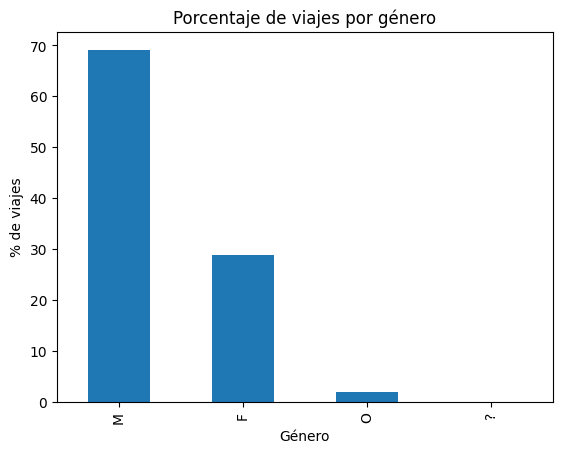

In [5]:
# Calcular % de viajes por género
genero = bicis["Genero_Usuario"].value_counts(normalize=True) * 100

genero.plot(kind="bar")
plt.title("Porcentaje de viajes por género")
plt.ylabel("% de viajes")
plt.xlabel("Género")
plt.show()

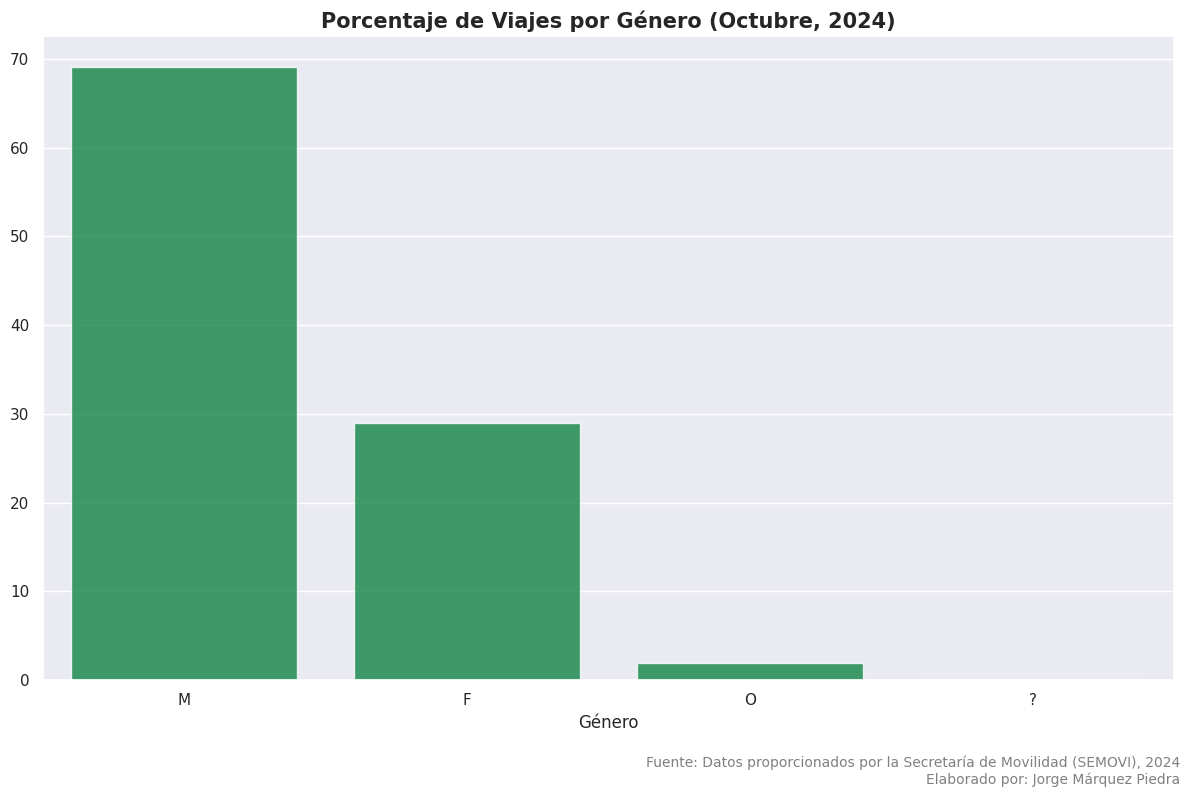

In [6]:
# Plot final
plt.figure(figsize=(12, 8))
sns.set_theme()
sns.barplot(x = genero.index, y = genero.values, color = '#009844', alpha = 0.8)
plt.title('Porcentaje de Viajes por Género (Octubre, 2024)', fontsize = 15, fontweight = 'bold')
plt.xlabel('Género')
plt.ylabel(None)
plt.figtext(0.99, 0.01, 'Fuente: Datos proporcionados por la Secretaría de Movilidad (SEMOVI), 2024\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.14)
plt.savefig('genero_viajes.png')
plt.show()

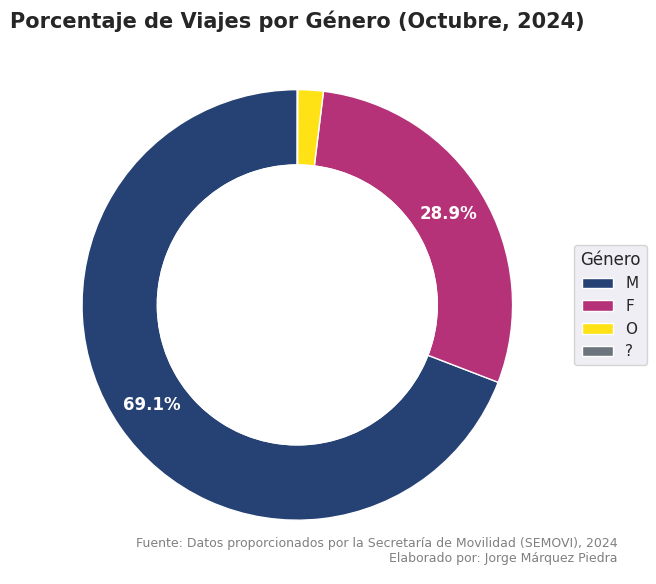

In [7]:
# Plot final
plt.figure(figsize=(8, 6))
sns.set_theme()

colors = {'M': '#264274', 'F': '#b53278', 'O': '#ffe216', '?': '#6C757D'}
pie_colors = [colors[gender] for gender in genero.index]

def autopct_func(pct):
    return f'{pct:.1f}%' if pct >= 2 else ''

wedges, texts, autotexts = plt.pie(
    genero.values,
    autopct=autopct_func,
    startangle=90,
    colors=pie_colors,
    pctdistance=0.82,
    wedgeprops=dict(width=0.35, edgecolor='white')
)

# Estilo de porcentajes
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_weight('bold')

centre_circle = plt.Circle((0, 0), 0.65, fc = 'white')
plt.gca().add_artist(centre_circle)

plt.legend(
    wedges,
    genero.index,
    title = "Género",
    loc = "center left",
    bbox_to_anchor = (1, 0.5)
)

plt.title(
    'Porcentaje de Viajes por Género (Octubre, 2024)',
    fontsize = 15,
    fontweight = 'bold'
)

plt.figtext(
    0.9, 0.05,
    'Fuente: Datos proporcionados por la Secretaría de Movilidad (SEMOVI), 2024\nElaborado por: Jorge Márquez Piedra',
    ha = 'right',
    fontsize = 9,
    color = 'gray'
)

plt.savefig('genero_viajes_dona.png')
plt.tight_layout()
plt.show()

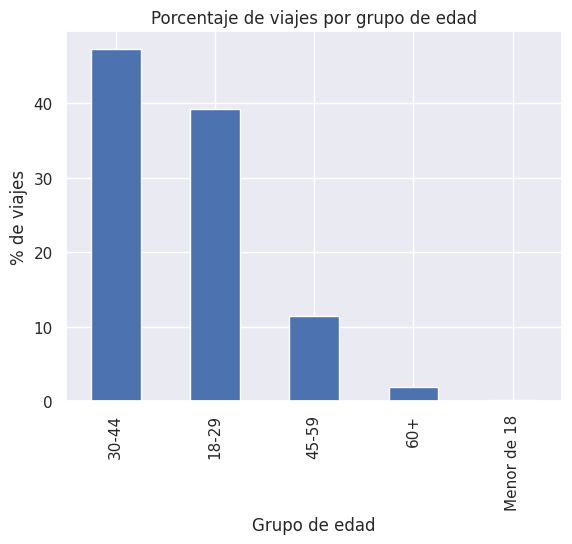

In [8]:
# Viajes por grupos de edad
def grupo_edad(edad):
    if edad < 18:
        return "Menor de 18"
    elif edad < 30:
        return "18-29"
    elif edad < 45:
        return "30-44"
    elif edad < 60:
        return "45-59"
    else:
        return "60+"

bicis["Grupo_Edad"] = bicis["Edad_Usuario"].apply(grupo_edad)

edad_pct = bicis["Grupo_Edad"].value_counts(normalize=True) * 100

edad_pct.plot(kind="bar")
plt.title("Porcentaje de viajes por grupo de edad")
plt.ylabel("% de viajes")
plt.xlabel("Grupo de edad")
plt.show()

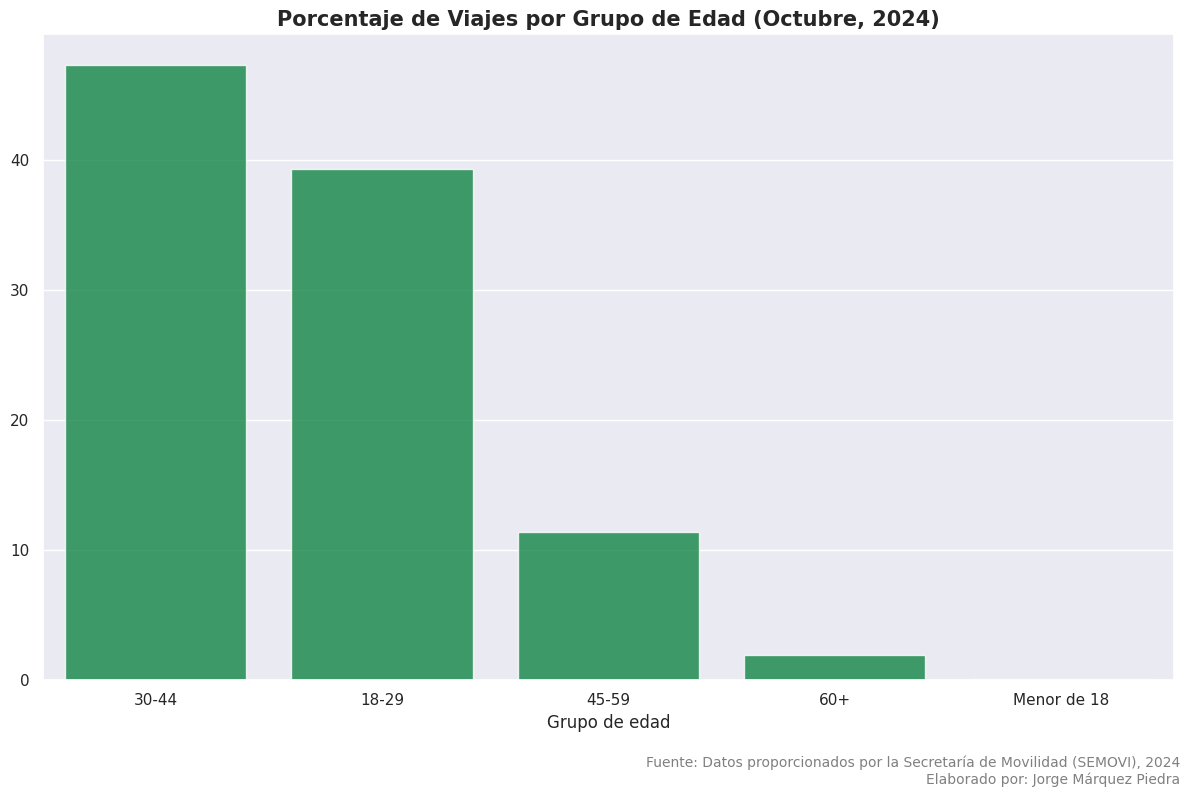

In [9]:
# Plot final
plt.figure(figsize=(12, 8))
sns.set_theme()
sns.barplot(x = edad_pct.index, y = edad_pct.values, color = '#009844', alpha = 0.8)
plt.title('Porcentaje de Viajes por Grupo de Edad (Octubre, 2024)', fontsize = 15, fontweight = 'bold')
plt.xlabel('Grupo de edad')
plt.ylabel(None)
plt.figtext(0.99, 0.01, 'Fuente: Datos proporcionados por la Secretaría de Movilidad (SEMOVI), 2024\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.14)
plt.savefig('edad_viajes.png')
plt.show()

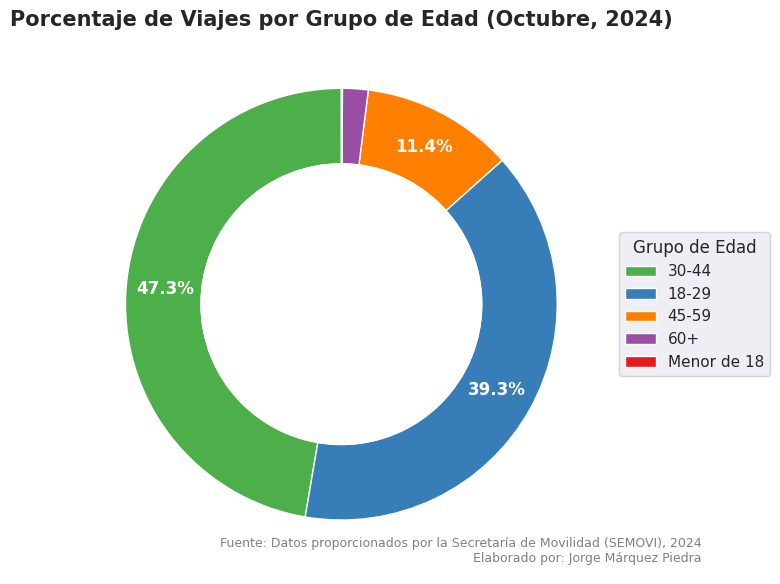

In [10]:
# Plot final
plt.figure(figsize=(8, 6))
sns.set_theme()

age_colors = ['#4daf4a', '#377eb8', '#ff7f00', '#984ea3', '#e41a1c']

color_map_edad = {group: age_colors[i] for i, group in enumerate(edad_pct.index)}
pie_colors_edad = [color_map_edad[group] for group in edad_pct.index]

# Función para ocultar porcentajes pequeños
def autopct_func(pct):
    return f'{pct:.1f}%' if pct >= 2 else ''

wedges, texts, autotexts = plt.pie(
    edad_pct.values,
    autopct = autopct_func,
    startangle = 90,
    colors = pie_colors_edad,
    pctdistance = 0.82,
    wedgeprops = dict(width = 0.35, edgecolor='white')
)

# Estilo de porcentajes
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_weight('bold')

centre_circle = plt.Circle((0, 0), 0.65, fc='white')
plt.gca().add_artist(centre_circle)

plt.legend(
    wedges,
    edad_pct.index,
    title = "Grupo de Edad",
    loc = "center left",
    bbox_to_anchor = (1, 0.5)
)

plt.title(
    'Porcentaje de Viajes por Grupo de Edad (Octubre, 2024)',
    fontsize = 15,
    fontweight = 'bold'
)

plt.figtext(
    0.9, 0.05,
    'Fuente: Datos proporcionados por la Secretaría de Movilidad (SEMOVI), 2024\nElaborado por: Jorge Márquez Piedra',
    ha = 'right',
    fontsize = 9,
    color = 'gray'
)

plt.tight_layout()
plt.savefig('edad_viajes_dona.png', dpi=300, bbox_inches='tight')
plt.show()

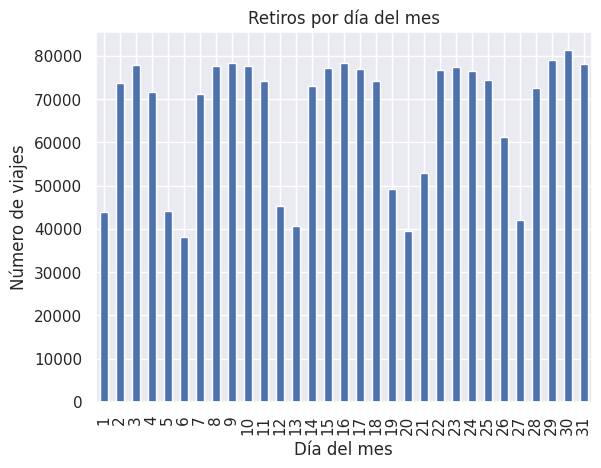

In [11]:
# Retiros por día
bicis["Dia_Mes"] = bicis["Fecha_Retiro"].dt.day

retiros_dia = bicis["Dia_Mes"].value_counts().sort_index()

retiros_dia.plot(kind="bar")
plt.title("Retiros por día del mes")
plt.xlabel("Día del mes")
plt.ylabel("Número de viajes")
plt.show()

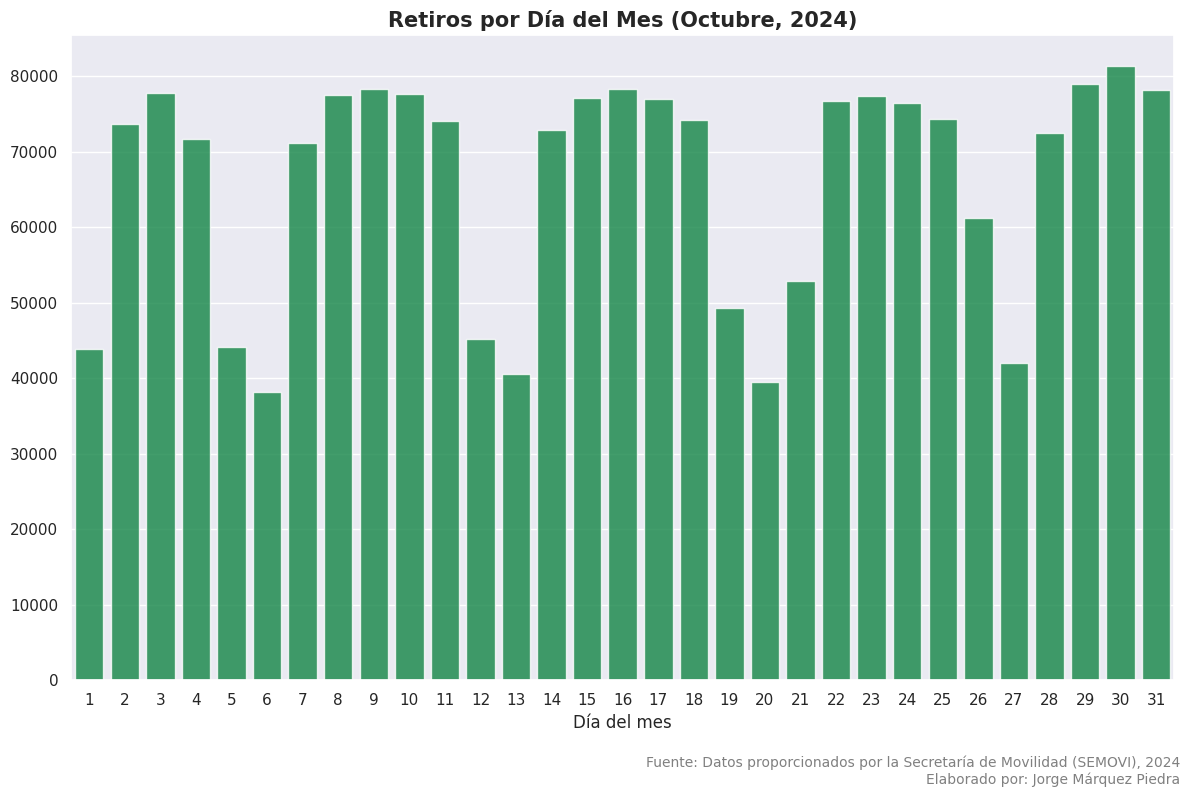

In [12]:
# Plot final
plt.figure(figsize=(12, 8))
sns.set_theme()
sns.barplot(x = retiros_dia.index, y = retiros_dia.values, color = '#009844', alpha = 0.8)
plt.title('Retiros por Día del Mes (Octubre, 2024)', fontsize = 15, fontweight = 'bold')
plt.xlabel('Día del mes')
plt.ylabel(None)
plt.figtext(0.99, 0.01, 'Fuente: Datos proporcionados por la Secretaría de Movilidad (SEMOVI), 2024\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.14)
plt.savefig('retiros_dia_mes.png')
plt.show()

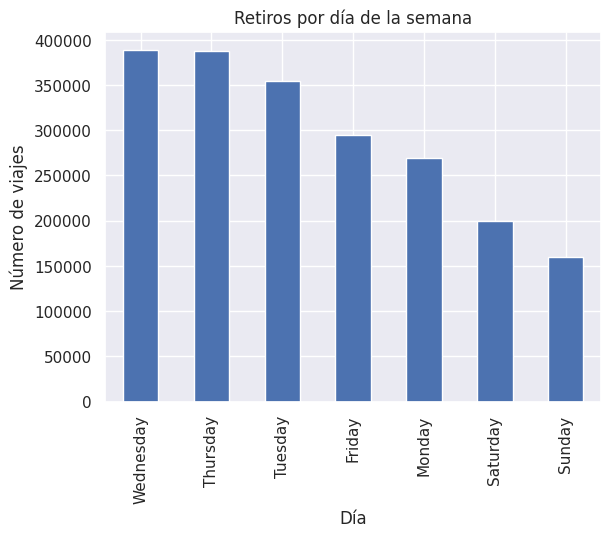

In [13]:
# Distribución de retiros por día de la semana
bicis["Dia_Semana"] = bicis["Fecha_Retiro"].dt.day_name()

retiros_semana = bicis["Dia_Semana"].value_counts()

retiros_semana.plot(kind="bar")
plt.title("Retiros por día de la semana")
plt.xlabel("Día")
plt.ylabel("Número de viajes")
plt.show()

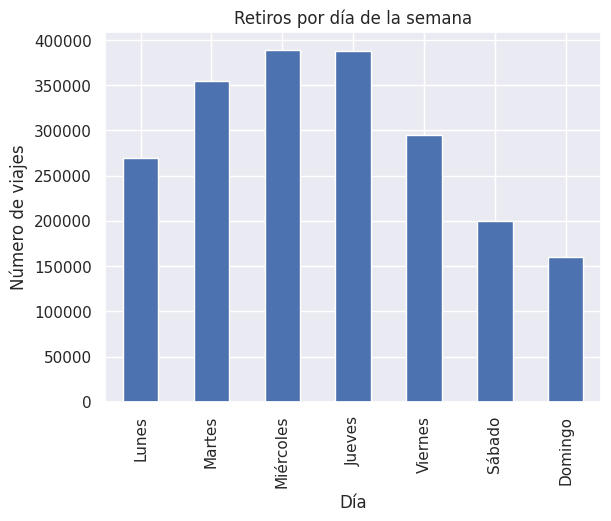

In [14]:
# Traducir los días de inglés a español
dia_mapping = {
    'Monday': 'Lunes',
    'Tuesday': 'Martes',
    'Wednesday': 'Miércoles',
    'Thursday': 'Jueves',
    'Friday': 'Viernes',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo'
}

bicis["Dia_Semana"] = bicis["Fecha_Retiro"].dt.day_name()
bicis["Dia_Semana"] = bicis["Dia_Semana"].map(dia_mapping)

orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

retiros_semana = bicis["Dia_Semana"].value_counts().reindex(orden_dias)

retiros_semana.plot(kind="bar")
plt.title("Retiros por día de la semana")
plt.xlabel("Día")
plt.ylabel("Número de viajes")
plt.show()

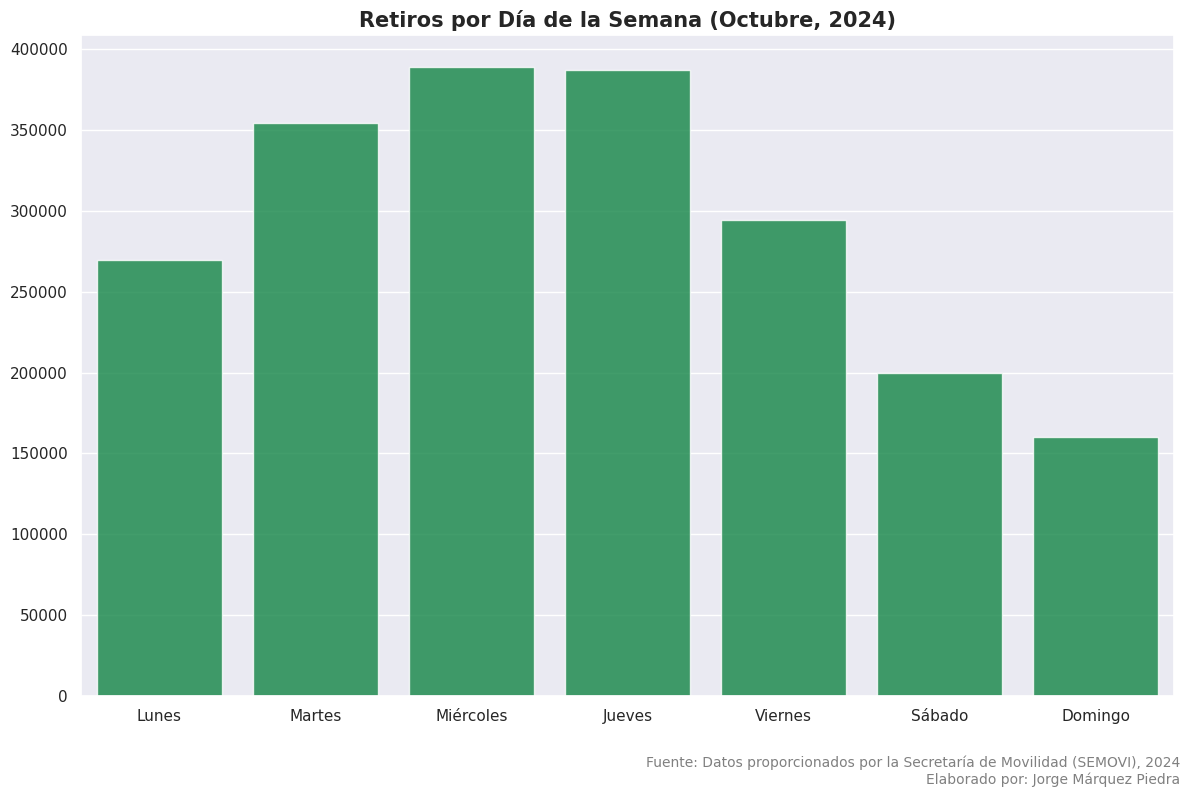

In [15]:
# Plot final
plt.figure(figsize=(12, 8))
sns.set_theme()
sns.barplot(x = retiros_semana.index, y = retiros_semana.values, color = '#009844', alpha = 0.8)
plt.title('Retiros por Día de la Semana (Octubre, 2024)', fontsize = 15, fontweight = 'bold')
plt.xlabel(None)
plt.ylabel(None)
plt.figtext(0.99, 0.01, 'Fuente: Datos proporcionados por la Secretaría de Movilidad (SEMOVI), 2024\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.savefig('retiros_dia_semana.png')
plt.show()

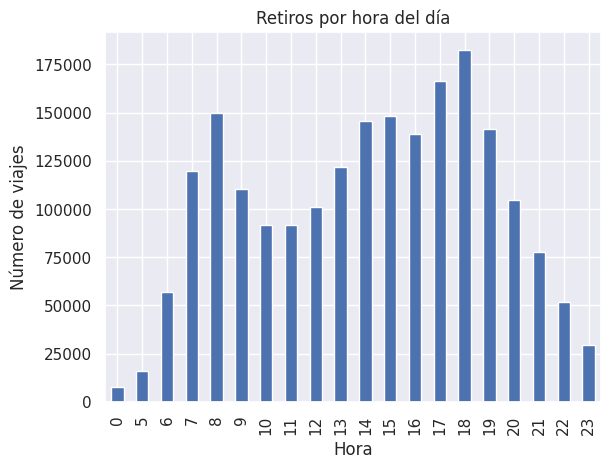

In [16]:
# Distribución de retiros por hora
bicis["Hora"] = bicis["FechaHora_Retiro"].dt.hour

# Conteo por hora
retiros_hora = bicis["Hora"].value_counts().sort_index()

# Gráfica
retiros_hora.plot(kind="bar")
plt.title("Retiros por hora del día")
plt.xlabel("Hora")
plt.ylabel("Número de viajes")
plt.show()

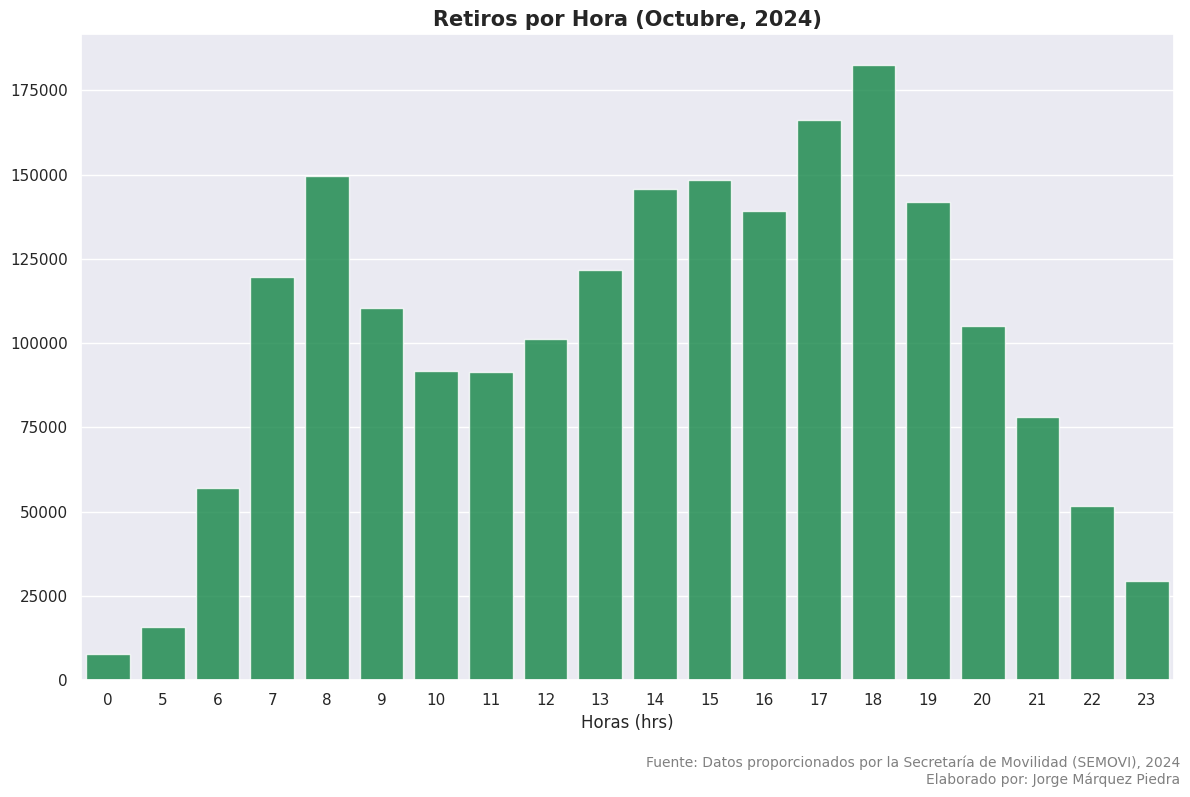

In [17]:
# Plot final
plt.figure(figsize=(12, 8))
sns.set_theme()
sns.barplot(x = retiros_hora.index, y = retiros_hora.values, color = '#009844', alpha = 0.8)
plt.title('Retiros por Hora (Octubre, 2024)', fontsize = 15, fontweight = 'bold')
plt.xlabel('Horas (hrs)')
plt.ylabel(None)
plt.figtext(0.99, 0.01, 'Fuente: Datos proporcionados por la Secretaría de Movilidad (SEMOVI), 2024\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.14)
plt.savefig('retiros_hora.png')
plt.show()

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

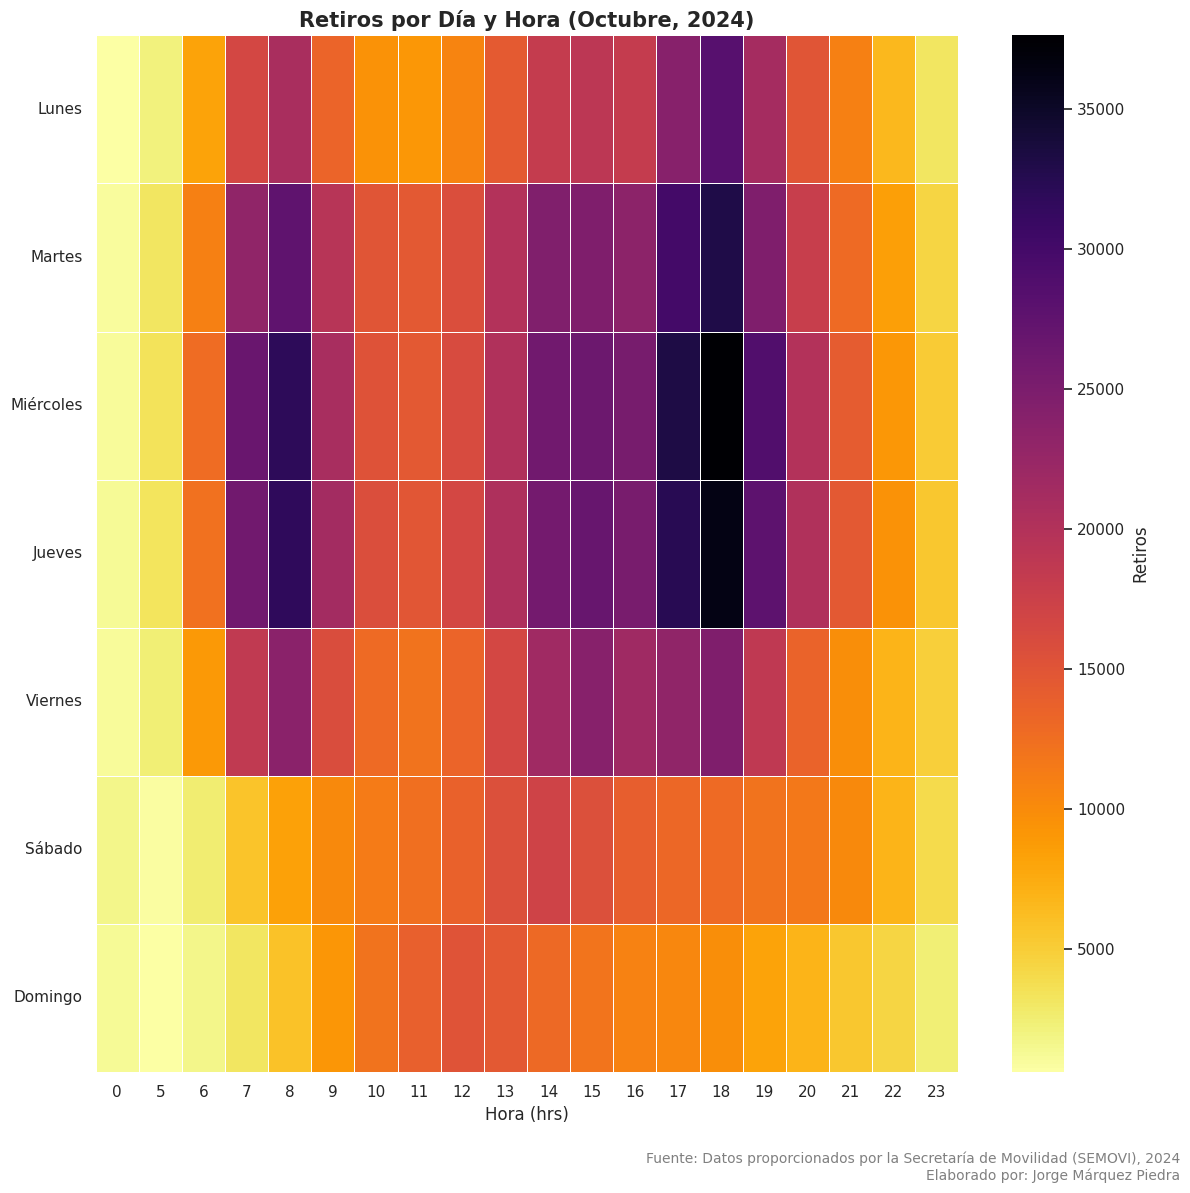

In [18]:
# Heatmap día y hora
# Orden correcto
orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

# Tabla pivot
pivot = pd.pivot_table(
    bicis,
    values = "Genero_Usuario",
    index = "Dia_Semana",
    columns = "Hora",
    aggfunc = "count"
).reindex(orden_dias)

plt.figure(figsize=(12, 12))
sns.set_theme()
sns.heatmap(pivot, cmap = "inferno_r", fmt = ".0f", linewidths = .5, cbar_kws = {'label': 'Retiros'})
plt.title('Retiros por Día y Hora (Octubre, 2024)', fontsize = 15, fontweight = 'bold')
plt.xlabel('Hora (hrs)')
plt.ylabel(None)
plt.xticks()
plt.yticks(rotation = 0)
plt.figtext(0.99, 0.01, 'Fuente: Datos proporcionados por la Secretaría de Movilidad (SEMOVI), 2024\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.10)
plt.savefig('retiros_dia_hora.png', dpi = 300)
plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

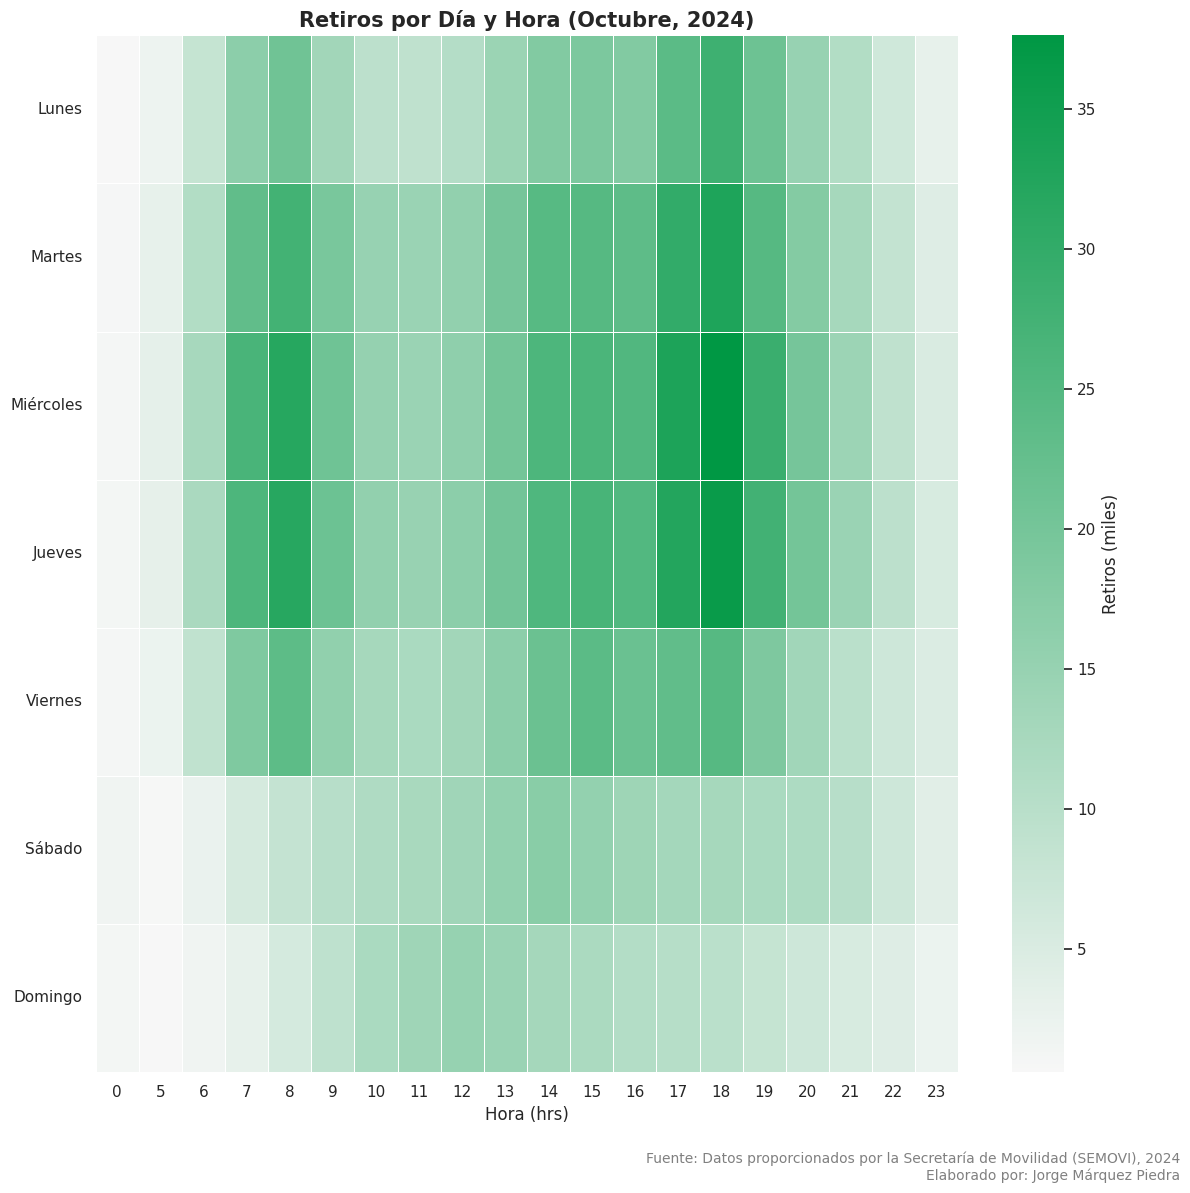

In [19]:
# Heatmap con color personalizado
from matplotlib.colors import LinearSegmentedColormap

# Dividir en miles el pivot
pivot = pivot / 1_000

# Crear paleta personalizada
custom_eb = LinearSegmentedColormap.from_list("eb_palette", ["#f7f7f7", "#009844"])

plt.figure(figsize=(12, 12))
sns.set_theme()
sns.heatmap(pivot, cmap = custom_eb, fmt = ".0f", linewidths = .5, cbar_kws = {'label': 'Retiros (miles)'})
plt.title('Retiros por Día y Hora (Octubre, 2024)', fontsize = 15, fontweight = 'bold')
plt.xlabel('Hora (hrs)')
plt.ylabel(None)
plt.xticks()
plt.yticks(rotation = 0)
plt.figtext(0.99, 0.01, 'Fuente: Datos proporcionados por la Secretaría de Movilidad (SEMOVI), 2024\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.10)
plt.savefig('retiros_dia_hora_personalizado.png', dpi = 300)
plt

In [20]:
# Duración promedio de viajes
duracion_promedio = bicis["Duracion_Min"].mean()

duracion_promedio

np.float64(15.803108320528784)

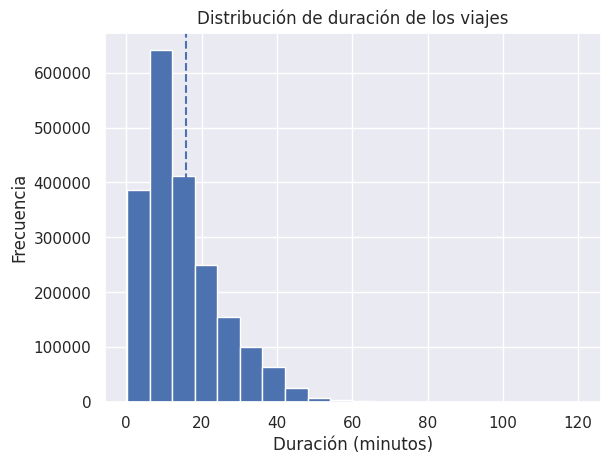

In [21]:
# Gráfica de Duración promedio de viajes
bicis[bicis["Duracion_Min"] < 120]["Duracion_Min"].plot(kind="hist", bins=20)
plt.axvline(duracion_promedio, linestyle="--")
plt.title("Distribución de duración de los viajes")
plt.xlabel("Duración (minutos)")
plt.ylabel("Frecuencia")
plt.show()

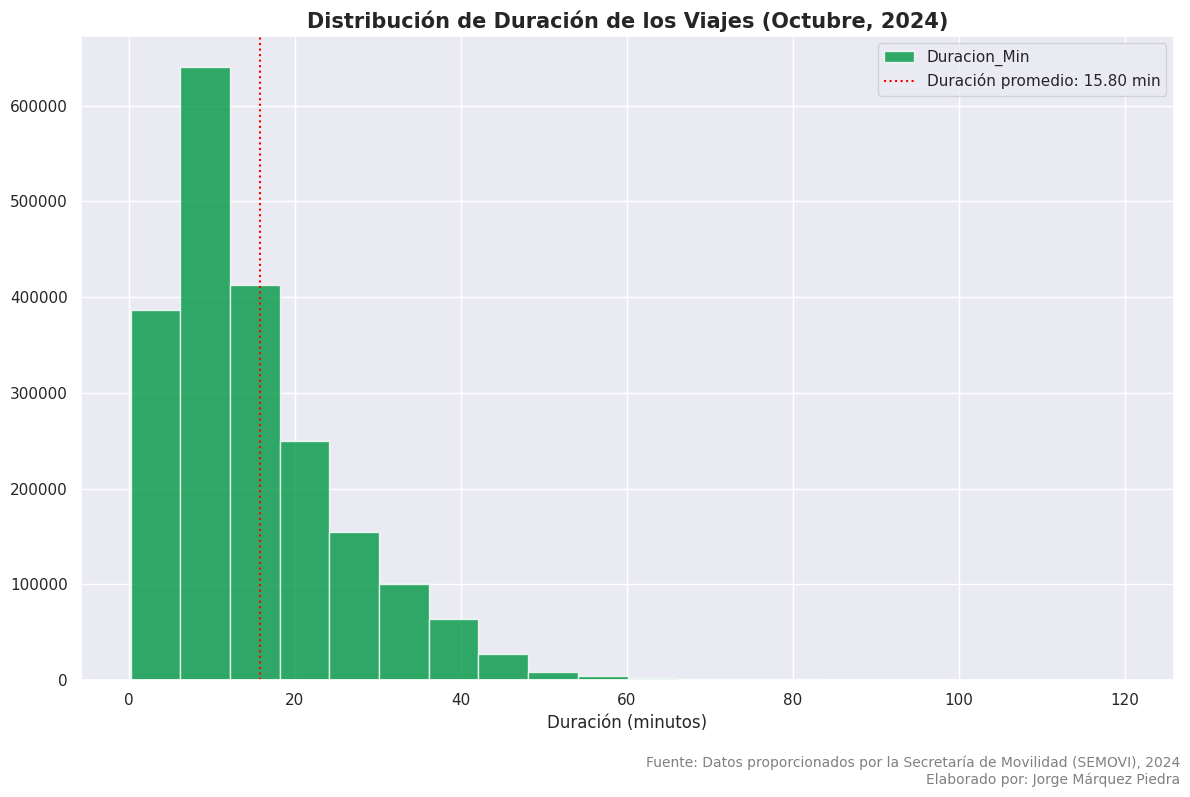

In [22]:
#Plot final
plt.figure(figsize=(12, 8))
sns.set_theme()
bicis[bicis["Duracion_Min"] < 120]["Duracion_Min"].plot(kind = "hist", bins = 20, color = '#009844', alpha = 0.8)
plt.axvline(duracion_promedio, linestyle = 'dotted', color='red', label=f'Duración promedio: {duracion_promedio:.2f} min')
plt.title('Distribución de Duración de los Viajes (Octubre, 2024)', fontsize = 15, fontweight = 'bold')
plt.xlabel('Duración (minutos)')
plt.ylabel(None)
plt.legend()
plt.figtext(0.99, 0.01, 'Fuente: Datos proporcionados por la Secretaría de Movilidad (SEMOVI), 2024\nElaborado por: Jorge Márquez Piedra', horizontalalignment='right', fontsize=10, color='gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.14)
plt.savefig('duracion_viajes_hist.png')
plt.show()

In [23]:
# Día de mayor demanda
mayor_dia = bicis["Fecha_Retiro"].value_counts().idxmax()
mayor_dia

Timestamp('2024-10-30 00:00:00')

In [24]:
# Día de mayor demanda por estaciones
mayor_dia_est = (
    bicis[bicis["Fecha_Retiro"] == mayor_dia]
    .groupby("Ciclo_Estacion_Retiro")
    .size()
    .reset_index(name="suma")
    .sort_values("suma", ascending=False)
)

##Leer archivo shapefile

In [25]:
# Cargar librerías
import geopandas as gpd

# Leer el shapefile de manzanas con población
shp_est = gpd.read_file('Cicloestaciones.shp')
print(shp_est.info())

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 677 entries, 0 to 676
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   sistema     677 non-null    object  
 1   num_cicloe  677 non-null    object  
 2   calle_prin  677 non-null    object  
 3   calle_secu  677 non-null    object  
 4   colonia     677 non-null    object  
 5   alcaldia    677 non-null    object  
 6   latitud     677 non-null    float64 
 7   longitud    677 non-null    float64 
 8   sitio_de_e  677 non-null    object  
 9   geometry    677 non-null    geometry
dtypes: float64(2), geometry(1), object(7)
memory usage: 53.0+ KB
None


<Axes: >

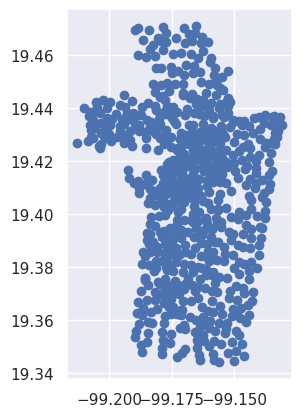

In [26]:
# Plot de la capa
shp_est.plot()

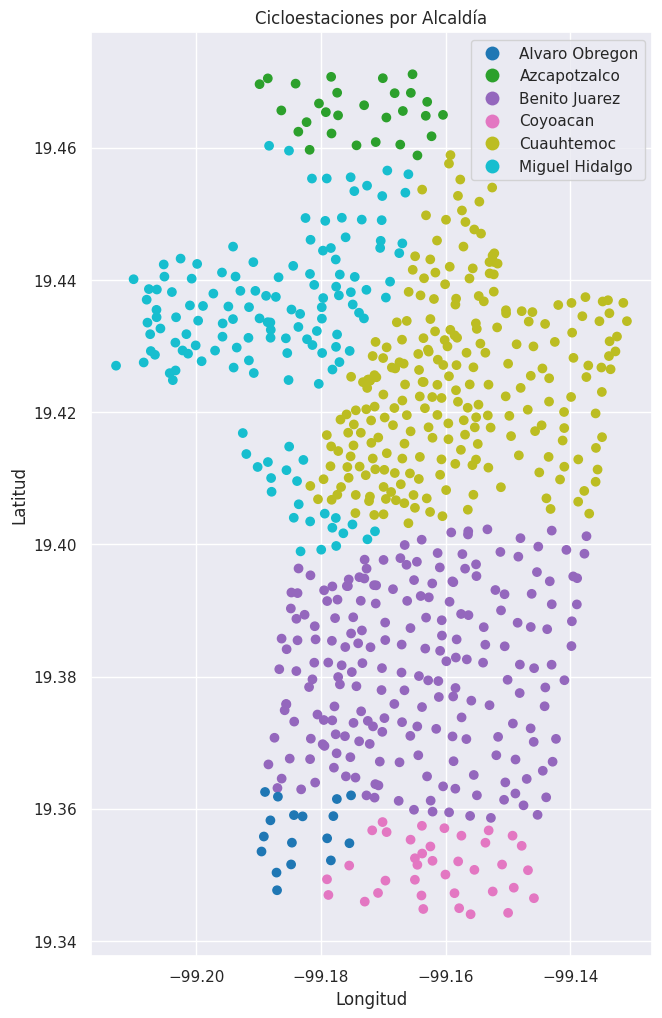

In [27]:
shp_est.plot(column = 'alcaldia', legend = True, figsize = (12, 12))
plt.title('Cicloestaciones por Alcaldía')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.show()

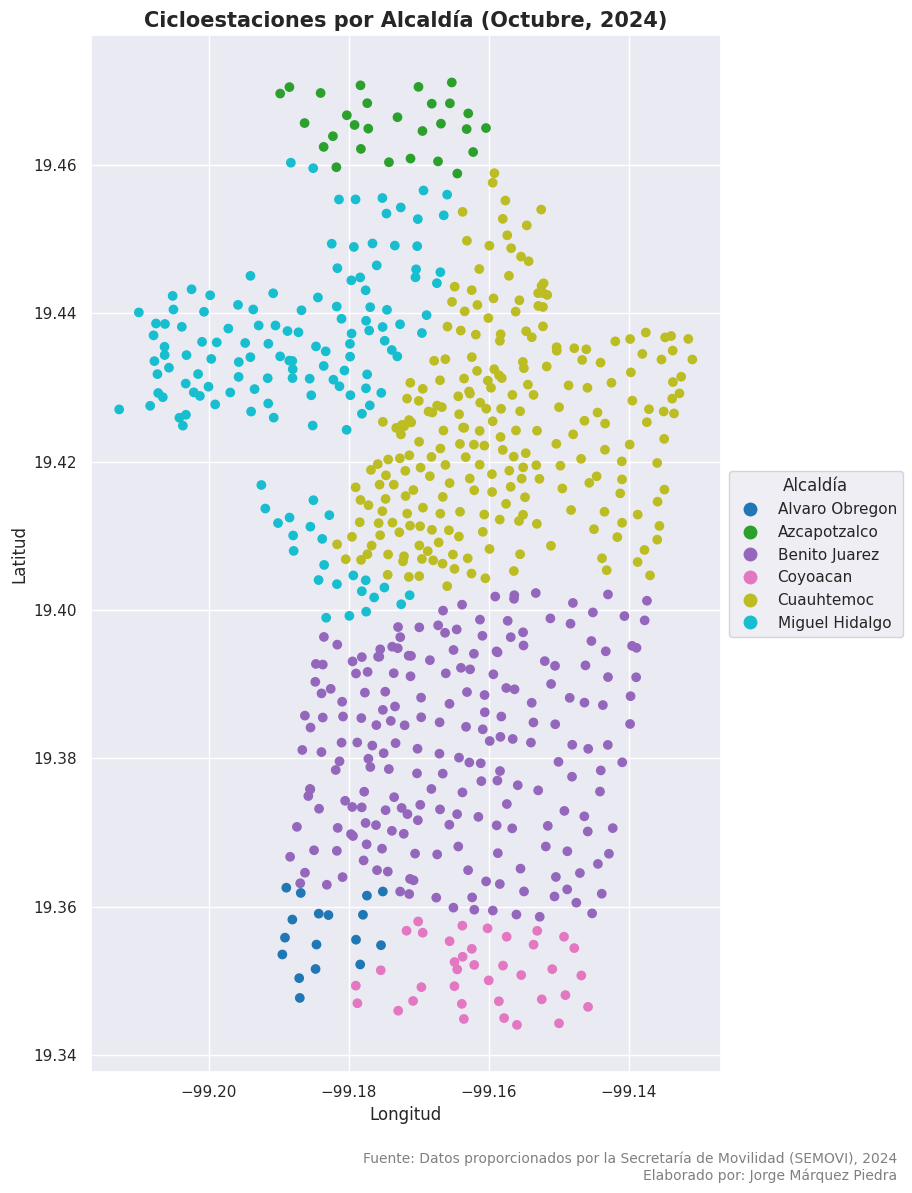

In [28]:
sns.set_theme()
ax = shp_est.plot(column = 'alcaldia', legend = True, figsize = (9, 12))
ax.set_title('Cicloestaciones por Alcaldía (Octubre, 2024)', fontsize = 15, fontweight = 'bold')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')

legend = ax.get_legend()
if legend:
    legend.set_loc('center left')
    legend.set_bbox_to_anchor((1, 0, 0.3, 1))
    legend.set_title('Alcaldía')

plt.figtext(0.99, 0.01, 'Fuente: Datos proporcionados por la Secretaría de Movilidad (SEMOVI), 2024\nElaborado por: Jorge Márquez Piedra', horizontalalignment = 'right', fontsize = 10, color = 'gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.10)
plt.savefig('cicloestaciones_alcaldia.png')
plt.show()

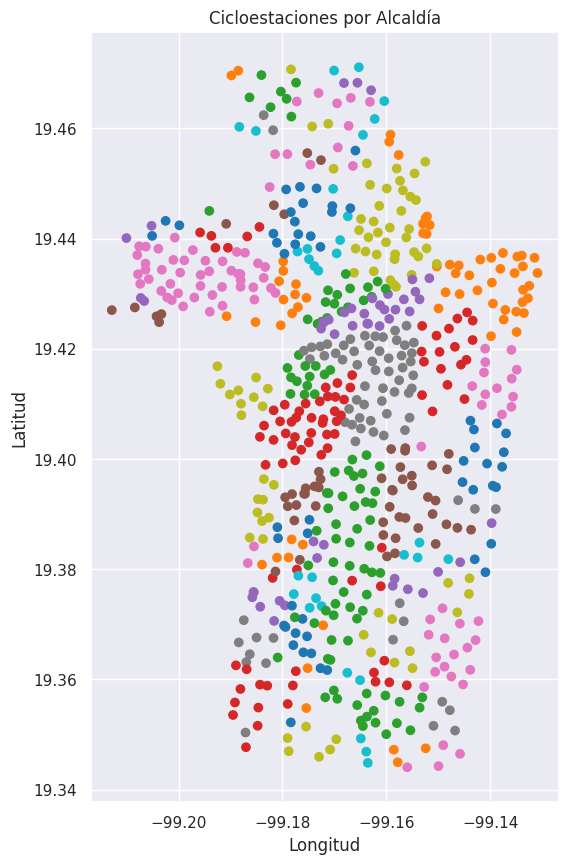

In [29]:
shp_est.plot(column = 'colonia', legend = False, figsize = (10, 10))
plt.title('Cicloestaciones por Alcaldía')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.show()

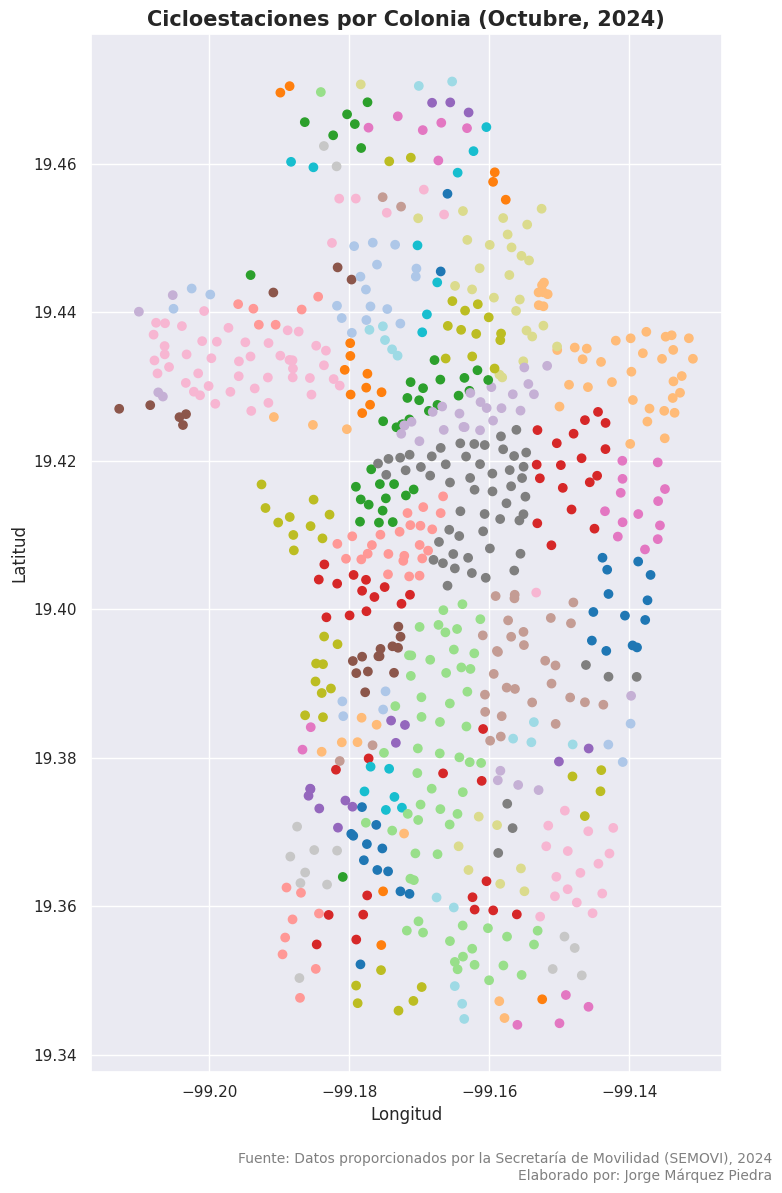

In [30]:
sns.set_theme()
ax = shp_est.plot(column = 'colonia', figsize = (8, 12), cmap = 'tab20', legend = False)
ax.set_title('Cicloestaciones por Colonia (Octubre, 2024)', fontsize = 15, fontweight = 'bold')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
plt.figtext(0.99, 0.01, 'Fuente: Datos proporcionados por la Secretaría de Movilidad (SEMOVI), 2024\nElaborado por: Jorge Márquez Piedra', horizontalalignment = 'right', fontsize = 10, color = 'gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.10)
plt.savefig('cicloestaciones_colonia.png')
plt.show()

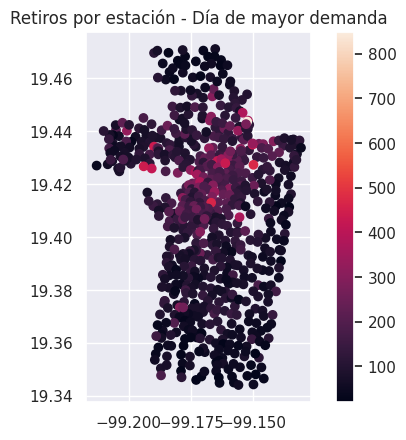

In [32]:
# Join de datos del día de mayor demanda

# Convertir a string ambos campos
mayor_dia_est["Ciclo_Estacion_Retiro"] = mayor_dia_est["Ciclo_Estacion_Retiro"].astype(str)
shp_est["num_cicloe"] = shp_est["num_cicloe"].astype(str)

# Join
shp_join = shp_est.merge(
    mayor_dia_est,
    left_on = "num_cicloe",
    right_on = "Ciclo_Estacion_Retiro",
    how = "left"
)

# Plot
shp_join.plot(column = "suma", legend = True)
plt.title("Retiros por estación - Día de mayor demanda")
plt.show()

<Figure size 1200x1000 with 0 Axes>

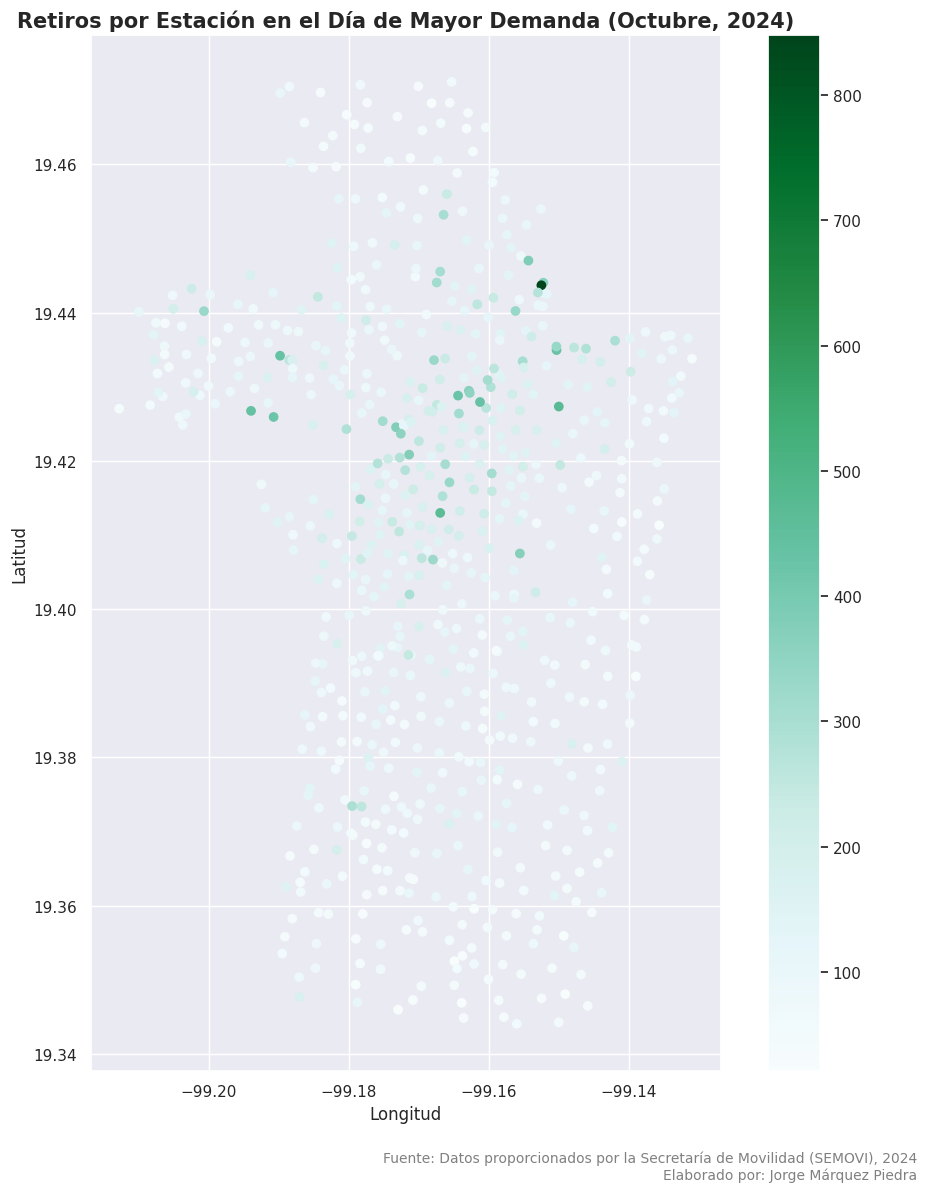

In [33]:
# Plot final
plt.figure(figsize = (12, 10))
sns.set_theme()
ax = shp_join.plot(column = "suma", figsize = (10, 12), cmap = 'BuGn', legend = True)
ax.set_title('Retiros por Estación en el Día de Mayor Demanda (Octubre, 2024)', fontsize = 15, fontweight = 'bold')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
plt.figtext(0.99, 0.01, 'Fuente: Datos proporcionados por la Secretaría de Movilidad (SEMOVI), 2024\nElaborado por: Jorge Márquez Piedra', horizontalalignment = 'right', fontsize = 10, color = 'gray')
plt.tight_layout()
plt.subplots_adjust(bottom = 0.10)
plt.savefig('retiros_dia_demanda_estaciones.png')
plt.show()

In [34]:
# Exportar capa
shp_join.to_file("dia_mayor_retiro_est.shp")
shp_join.to_file("dia_mayor_retiro_est.gpkg", driver = "GPKG")

/tmp/ipykernel_7001/2166122652.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  shp_join.to_file("dia_mayor_retiro_est.shp")
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Ciclo_Estacion_Retiro' to 'Ciclo_Esta'
  ogr_write(
